# Example: Binomial Lattice Simulation of Equity Share Price using Real-World Probabilities
In this example, we will construct a binomial lattice model to simulate future equity share prices using real-world probabilities estimated from historical data.

> __Learning Objectives:__
>
> The objective of this example is to familiarize students with applying simple probability mass functions to predict future uncertain quantities such as commodity prices, equity share prices, interest rates, etc. After completing this example, students should be able to:
>
> * __Model structure:__ Describe a binomial lattice as a state that moves to one of two successor prices at each step, with the move magnitudes and transition probability fixed in advance. Explain how repeating that step generates a distribution of prices at any future horizon.
> * __Parameter estimation:__ Estimate the up and down move magnitudes and the real-world transition probability from a historical growth-rate sample. Populate the lattice with those estimates so the move sizes and their probabilities come from the sample rather than from a chosen convention.
> * __Model evaluation:__ Compare model predictions with actual market observations using model-based standard-deviation bands. Separate an in-sample check from an out-of-sample test, and measure how often the market stays inside the bands on data the parameters never saw.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # activate the course environment and load shared lattice helpers

  Activating 

project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Data
We gathered daily open-high-low-close (OHLC) data for each firm in the [S&P500](https://en.wikipedia.org/wiki/S%26P_500) from `01-03-2014` until `12-31-2024`, along with data for a few exchange-traded funds and volatility products during that time period. 

Let's load the `original_dataset::Dict{String,DataFrame}` variable by calling [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet) and remove firms that do not have the maximum number of trading days. The cleaned dataset $\mathcal{D}$ will be stored in the `dataset` variable.

In [2]:
original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"]; # map ticker symbols to 2014-2024 price DataFrames

Not all tickers in our dataset have the maximum number of trading days for various reasons, e.g., acquisition or delisting events. Let's collect only those tickers with the maximum number of trading days.

First, let's compute the number of records for a firm that we know has the maximum value, e.g., `AAPL`, and save that value in the `maximum_number_trading_days::Int64` variable:

In [3]:
maximum_number_trading_days = original_dataset["AAPL"] |> nrow # use a full-history ticker to establish the required row count

2767

Now, let's iterate through our data and collect only tickers with `maximum_number_trading_days` records. We'll save that data in the `dataset::Dict{String,DataFrame}` variable:

In [4]:
dataset = let

    # Initialize -
    dataset = Dict{String, DataFrame}(); # cleaned mapping from ticker symbols to complete histories

    # Retain firms with complete histories; dictionary traversal order is not guaranteed -
    for (ticker, data) ∈ original_dataset # unpack one ticker-history pair
        if (nrow(data) == maximum_number_trading_days) # exclude shorter listing or delisting histories
            dataset[ticker] = data; # preserve the complete DataFrame under its ticker symbol
        end
    end
    dataset; # return the cleaned dictionary from the let block
end;

How many firms do we have with the full number of trading days? Let's use [the `length(...)` function](https://docs.julialang.org/en/v1/base/collections/#Base.length), which works for dictionaries in addition to arrays, sets, and other collections.

In [5]:
length(dataset) # display the number of retained firms

424

Finally, let's get a list of the firms in our cleaned dataset and sort them alphabetically. We store the sorted firm ticker symbols in the `list_of_tickers::Array{String,1}` variable.

In [6]:
list_of_tickers = keys(dataset) |> collect |> sort # alphabetized ticker order for reproducible selection and display

424-element Vector{String}:
 "A"
 "AAL"
 "AAP"
 "AAPL"
 "ABBV"
 "ABT"
 "ACN"
 "ADBE"
 "ADI"
 "ADM"
 "ADP"
 "ADSK"
 "AEE"
 ⋮
 "WST"
 "WU"
 "WY"
 "WYNN"
 "XEL"
 "XOM"
 "XRAY"
 "XYL"
 "YUM"
 "ZBRA"
 "ZION"
 "ZTS"

### Constants
Finally, let's set some constants we'll use later in this notebook. The comments describe the constants, their units, and permissible values.

In [7]:
# Set the shared simulation horizon and trading-time convention -
TSIM = 63; # number of one-trading-day lattice steps, approximately one quarter
Δt = (1.0/252); # one trading-day step in units of trading years

___

## Task 1: Test the lattice model using an example from Hull
In this task, we'll run our lattice code on a worked example from Chapter 13 of Hull and check that it reproduces the published share prices. Reproducing a published answer is a check on the implementation before we point the code at real data.

The lattice in this example has three levels (`L=0,1,2`), with an initial share price of $S_{\circ}=20.0$ USD. An `up` move has a probability of `p = 0.6523` and a magnitude of `u = 1.1`, while a `down` move has a magnitude of `d = 0.9`.

The model needs five inputs before it can run. We set the initial share price (a `Float64`), the number of steps to simulate, which is how many levels the tree grows beyond the root (an `Int64`), the up and down move magnitudes (`Float64` values), and the probability of an up move (a `Float64`):

In [8]:
Sₒ,T,u,d,p = 20.0,2,1.1,0.9,0.6523; # initial USD/share, steps, up/down factors, and up probability from Hull

Once these values are set, we use [the `build(…)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.build-Tuple{Type{MyBinomialEquityPriceTree},%20NamedTuple}) to create an empty lattice model of [type `MyBinomialEquityPriceTree`](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.MyBinomialEquityPriceTree), which is then passed to [the `populate(…)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.populate-Tuple{MyBinomialEquityPriceTree}) using the [Julia piping `|>` operator](https://docs.julialang.org/en/v1/manual/functions/#Function-composition-and-piping). 

The [`populate(…)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.populate-Tuple{MyBinomialEquityPriceTree}) calculates the prices and probabilities of each node, which are of [type `MyBiomialLatticeEquityNodeModel`](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.MyBiomialLatticeEquityNodeModel), in the tree:

In [9]:
# Build the tree parameters, then populate node prices and probabilities from the root -
test_hull_model = build(MyBinomialEquityPriceTree, (
        u = u, d = d, p = p)) |> (x-> populate(x, Sₒ = Sₒ, h = T)); # levels 0 through T

In [10]:
typeof(test_hull_model) |> T-> fieldnames(T) # display the stored fields of the populated tree type

(:u, :d, :p, :μ, :T, :connectivity, :levels, :ΔT, :data)

### Check: Do we reproduce the Hull tree values?
Let's compare the price values we calculated to those reported by Hull. 

> __Test:__ First, we populate the `hull_price_dictionary` dictionary, which holds `key=>value` pairs encoding the actual data for each node in the tree. In this dictionary, the `keys` are the node indices, while the `values` in the dictionary are the price values at that node. Then, we'll compare these values with those calculated in our lattice model.

Build the dictionary of Hull prices:

In [12]:
hull_price_dictionary = Dict(0=>20.0, 1=>22.0,2=>18.0,3=>24.2,4=>19.8,5=>16.2); # published USD/share values keyed by zero-based node id

Now, let's build a table of the Hull values and compare these to our computed values using [the `pretty_table(...)` function exported by the `PrettyTables.jl` package](https://github.com/ronisbr/PrettyTables.jl) within a for loop. 

For each iteration of the for loop:
* We capture the node index `i`, the share price from Hull, and our computed price at that node from the binomial tree
* We use the [isapprox function](https://docs.julialang.org/en/v1/base/math/#Base.isapprox) with a relative tolerance `rtol = 1e-4` to check whether our price matches Hull's. The check reports `true` when the two agree and `false` when they do not

What do we observe?

In [13]:
let

    # Initialize -
    number_of_nodes = length(test_hull_model.data); # total nodes across levels 0 through T
    hull_test_data_table = DataFrame(); # one validation row per node
    
    # Populate the comparison table by zero-based model node identifier -
    for i ∈ 0:(number_of_nodes-1) # model dictionaries use node ids 0,...,number_of_nodes-1
        
        row_data = ( # published value, computed value, and numerical agreement
            node = i,
            hull_price = hull_price_dictionary[i],
            our_price =  test_hull_model.data[i].price, 
            isapproxequal = isapprox(hull_price_dictionary[i], test_hull_model.data[i].price, rtol=1e-4) # relative tolerance for floating-point arithmetic
        );
        
        push!(hull_test_data_table, row_data) # append the named tuple as a DataFrame row
    end
    # Display the node-by-node implementation check -
    pretty_table(hull_test_data_table, 
            table_format = TextTableFormat(borders = text_table_borders__compact))
end;

 ------- ------------ ----------- ---------------
   node   hull_price   our_price   isapproxequal 
  Int64      Float64     Float64            Bool 
 ------- ------------ ----------- ---------------
      0         20.0        20.0            true
      1         22.0        22.0            true
      2         18.0        18.0            true
      3         24.2        24.2            true
      4         19.8        19.8            true
      5         16.2        16.2            true
 ------- ------------ ----------- ---------------


___

## Task 2: Estimate lattice parameters from historical data
In this task, we'll estimate the three lattice parameters $u$, $d$, and $p$ from historical daily prices, then simulate the share price forward. This is the step that turns the lattice from a textbook exercise into a model of an actual stock.

> __Parameter Definitions__
>
>* The $p$ parameter represents the probability of a share price increase or an `up` move between two consecutive periods $j\rightarrow{j+1}$. Since a binary lattice model only allows `up` and `down` moves, the probability of a `down` move is $1-p$.
>* The $u$ parameter represents the magnitude of an `up` move. If $S_{j}$ denotes the share price in period $j$, and $S_{j+1}$ is the share price in the next period, then an `up` move results in $S_{j+1} = u\cdot{S}_{j}$.
>* The $d$ parameter represents the magnitude of a `down` move. If $S_{j}$ denotes the share price in period $j$, and $S_{j+1}$ is the share price in the next period, then a `down` move results in $S_{j+1} = d\cdot{S}_{j}$.

To start, let's select a firm from the dataset to explore.

In [14]:
# Select one firm; uncomment the first assignment to randomize the example -
# random_firm_ticker = rand(list_of_tickers); # sample a ticker uniformly from the retained universe
random_firm_ticker = "AAPL" # fixed ticker makes the displayed example reproducible
random_firm_index = findfirst(x-> x == random_firm_ticker, list_of_tickers); # alphabetical display position
random_firm_data = dataset[random_firm_ticker]; # complete 2014-2024 price history

### Estimate the u, d, and probability p parameters from the data
Let's estimate the up $u$ and down $d$ factors and the probability $p$ from historical data.

__Initialize__: Given the growth rate sequence $\{g_{2},g_{3},\dots,g_{T}\}$ for firm $(i)$ (we omit the superscript $i$ for simplicity) and a time step $\Delta{t} > 0$ (units: years), initialize an empty up-factor list $U$ and an empty down-factor list $D$.

1. For $t = 2,3,\dots,T$, __do__:
    - If $g_{t} > 0$, then append $e^{g_{t}\Delta{t}}$ to the up-factor collection $U$.
    - If $g_{t} < 0$, then append $e^{g_{t}\Delta{t}}$ to the down-factor collection $D$.
    - If $g_{t} = 0$, skip (no price change).
2. Compute the up factor $u$ as the mean of the up factors collection $U$: $u = \frac{1}{|U|} \sum_{v \in U} v$.
3. Compute the down factor $d$ as the mean of the down factors collection $D$: $d = \frac{1}{|D|} \sum_{v \in D} v$.
4. Compute the probability $p$ as the fraction of all observed steps that are up moves: $p = |U|/(T-1)$, where a zero-change day counts in the denominator but joins neither collection. The estimator requires at least one up move and one down move in the sample.

We use daily data, so the natural time frame between $S_{j-1}$ and $S_{j}$ is a single day. However, it is more convenient to use an annualized value for the $g$ parameter, so we let $\Delta{t} = 1/252$, i.e., the fraction of a year that corresponds to a single trading day.

The [`log_growth_matrix(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix) takes the cleaned dataset $\mathcal{D}$, which contains $T$ days of data for each firm, and our selected ticker, and computes the growth rate series for that firm as a function of time. 

The data is returned as a length $T-1$ vector, one growth value per trading-day step. We store the data in the `log_growth_array::Array{Float64,1}` variable:

In [16]:
log_growth_array = log_growth_matrix(dataset, random_firm_ticker) # annualized daily growth rates; default Δt is 1/252 trading year

2766-element Vector{Float64}:
 -1.9954223478275546
  0.15124876922831154
  0.9224750663536962
 -1.4261203338251638
 -3.0008957287125435
  1.5049147899343094
  2.9156076155145367
  6.502627170431676
 -1.2561327051214097
 -4.024741418592851
  0.3164555755863404
  3.1033658421029613
 -0.6383305505446158
  ⋮
  0.00935838698715206
  2.702995377102388
  2.5465265271513293
 -2.325529514930973
 -0.7888121514647656
  3.27667430452004
  1.6089944655721826
  2.6547619721872575
  1.4556917537856608
 -3.6286559032528003
 -2.934268163874707
 -1.5398398549769603

Using the `log_growth_array::Array{Float64,1}`, we compute the expected up factor $\bar{u}$, expected down factor $\bar{d}$, and estimated up probability $\bar{p}$ by passing the growth-rate data to a `RealWorldBinomialProbabilityMeasure` instance.

> __Syntax sugar__: [The `RealWorldBinomialProbabilityMeasure` type](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.RealWorldBinomialProbabilityMeasure) is constructed with `RealWorldBinomialProbabilityMeasure()`, and the instance itself is callable: Julia dispatches the call to a functor method that computes $\bar{u}$, $\bar{d}$, and $\bar{p}$ from the growth rate time series in the `log_growth_array::Array{Float64,1}` variable. So we construct an object, then call it like a function. This is a neat Julia trick, right?

What values did we obtain for our selected firm?

In [17]:
(ū,d̄,p̄) = (RealWorldBinomialProbabilityMeasure())(log_growth_array; Δt = (1.0/252.0)) # mean up/down factors and observed up frequency

(1.010594785254532, 0.9893009316134485, 0.5509761388286334)

### Build binomial lattice model using historical $(u,d,p)$ parameters
Let's construct an instance of [the `MyBinomialEquityPriceTree` type](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.MyBinomialEquityPriceTree) using the estimated values for `(u,d,p)`. This enables us to calculate the prices and probabilities in the tree. We store the populated model in the variable `random_test_model` for future use.

We use the `TSIM` constant (set in the Setup section) as the number of future trading days to simulate. Time steps are represented in the tree as levels `L = 0,1,..., TSIM`, where each level represents $\Delta{t}$ units of time, which is a trading day. 

Next, we randomly specify the `start_index` as the trading day index in the dataset, which will serve as the tree's starting point or `L = 0`. Finally, we set the variable `Sₒ`, which corresponds to the initial price per share at the root of the tree. We use the [volume-weighted average price (VWAP)](https://en.wikipedia.org/wiki/Volume-weighted_average_price) as the initial condition:

In [18]:
# Select a complete in-sample window of TSIM observations -
start_index = rand(1:(maximum_number_trading_days - TSIM + 1)) # first Julia row in the window
stop_index = start_index + TSIM # exclusive upper row index
println("Visualize Firm-$(random_firm_index) between trading days ($(start_index) -> $(stop_index - 1))")

Visualize Firm-4 between trading days (2315 -> 2377)


In [19]:
# Initialize and populate the fitted real-world lattice -
Sₒ = random_firm_data[start_index,:volume_weighted_average_price]; # root VWAP, USD/share
random_test_model = build(MyBinomialEquityPriceTree, (
    u = ū, d = d̄, p = p̄)) |> (model -> populate(model, Sₒ = Sₒ, h = TSIM)); # levels 0 through TSIM
println("Starting simulation from Sₒ = $(Sₒ) USD/share")

Starting simulation from Sₒ = 151.7861 USD/share


#### Visualize price distribution at tree level L
__Unhide__ the code block below to see how we plotted the distribution of possible share prices and their associated probabilities at level `L = 10` of our binomial tree. 

> __What do we expect?__ We expect to see a discrete probability distribution where each possible price outcome has a specific probability based on the number of paths that lead to that price level. The distribution should reflect the binomial nature of our model, with probabilities concentrated around the most likely price outcomes.

What do we observe?

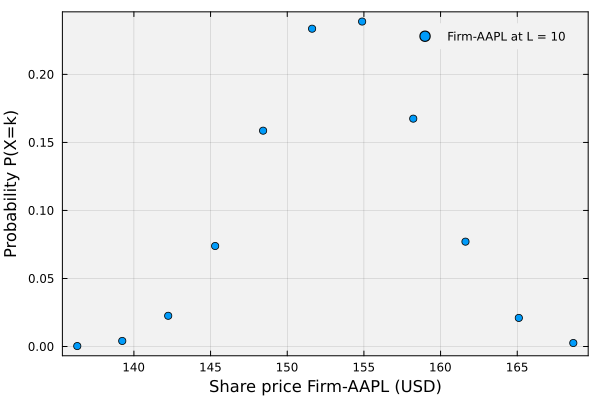

In [20]:
let
    # Extract prices and probability masses from one tree level -
    L = 10; # financial level, measured in trading-day steps from the root
    price_array = random_test_model.levels[L] .|> x-> random_test_model.data[x].price # USD/share outcomes
    probability_array = random_test_model.levels[L] .|> x-> random_test_model.data[x].probability; # aligned masses

    # Display the discrete price distribution at level L -
    scatter(price_array, probability_array, label="Firm-$(random_firm_ticker) at L = $(L)")
    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);
    xlabel!("Share price Firm-$(random_firm_ticker) (USD)", fontsize=18)
    ylabel!("Probability P(X=k)", fontsize=18)
end

### Visualize binomial lattice simulation
Next, let's examine how the binomial model simulations compare with market observations. In particular, we'll compute the expected value and the variance of the simulated price as a function of time, i.e., at each level in the tree using the local [`𝔼(...)`](src/Compute.jl) and [`Var(...)` functions](src/Compute.jl).

The `levels` array holds the indices of the tree levels, i.e., the time slices. The [`𝔼(...)`](src/Compute.jl) and [`Var(...)` functions](src/Compute.jl) take the `random_test_model` tree model and the `levels` array and return the expectation and the variance, respectively.

In [21]:
# Compute price moments for the TSIM plotted levels, including root level 0 -
levels = [k for k ∈ 0:(TSIM-1)] # financial levels map to Julia output rows k + 1
expectation = 𝔼(random_test_model, levels); # columns: level index and expected USD/share
variance = Var(random_test_model, levels); # columns: level index and price variance in (USD/share)^2

#### Summary
__Unhide__ the code block below to see how we plotted the model simulations and the observed prices for the selected firm using a binomial lattice model.

The dashed line represents the expected share price predicted by the lattice model, while the shaded regions denote the expectation plus or minus $z\sigma$ for $z=$ `1.0, 1.96, 2.576`. The solid red line with circles represents the [observed VWAP price](https://en.wikipedia.org/wiki/Volume-weighted_average_price) for this firm and date range.

Whether the observed price stays inside those bands depends on the ticker and the random start date, so the answer can change every time this notebook is rerun.

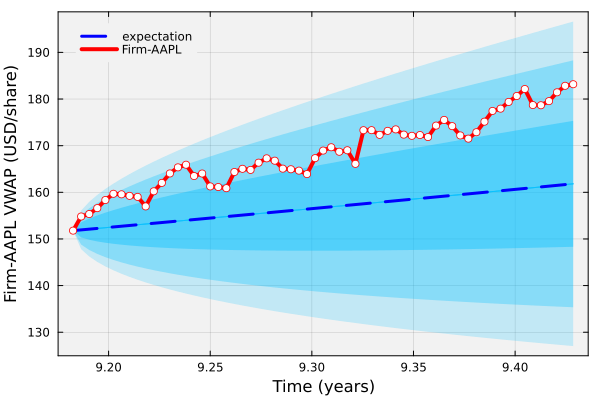

In [22]:
let 

    # Compute mean-plus-or-minus-z-standard-deviation price bands -
    L68 = expectation[:,2] .- sqrt.(variance[:,2]) # lower one-standard-deviation band, USD/share
    U68 = expectation[:,2] .+ sqrt.(variance[:,2]) # upper one-standard-deviation band, USD/share
    L95 = expectation[:,2] .- 1.96*sqrt.(variance[:,2]) # lower Normal-reference 95% band
    U95 = expectation[:,2] .+ 1.96*sqrt.(variance[:,2]) # upper Normal-reference 95% band
    L99 = expectation[:,2] .- 2.576*sqrt.(variance[:,2]) # lower Normal-reference 99% band
    U99 = expectation[:,2] .+ 2.576*sqrt.(variance[:,2]) # upper Normal-reference 99% band

    T_range = range(start_index,stop=stop_index-1,step=1) |> collect # dataset row indices in the scored window
    T_sim = T_range*Δt .- Δt # convert row indices to trading years from the dataset's first row

    # Display model bands, expected price, and aligned observed VWAP -
    plot(T_sim, expectation[:,2], fillrange=L68, c=:deepskyblue1, alpha=0.4, label="")
    plot!(T_sim, expectation[:,2], fillrange=U68, c=:deepskyblue1, alpha=0.4, label="")
    plot!(T_sim, expectation[:,2], fillrange=L95, c=:deepskyblue1, alpha=0.3, label="")
    plot!(T_sim, expectation[:,2], fillrange=U95, c=:deepskyblue1, alpha=0.3, label="")
    plot!(T_sim, expectation[:,2], fillrange=L99, c=:deepskyblue1, alpha=0.2, label="")
    plot!(T_sim, expectation[:,2], fillrange=U99, c=:deepskyblue1, alpha=0.2, label="")
    plot!(T_sim, expectation[:,2],c=:blue, lw=3,ls=:dash, label="expectation")
    plot!(T_sim, random_firm_data[levels .+ start_index, :volume_weighted_average_price],  
        lw=4, c=:red, label="Firm-$(random_firm_ticker)", legend = :topleft)
    scatter!(T_sim, random_firm_data[levels .+ start_index, :volume_weighted_average_price], label="", 
        msc=:red, mc=:white)

    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);

    xlabel!("Time (years)", fontsize=18)
    ylabel!("Firm-$(random_firm_ticker) VWAP (USD/share)", fontsize=18)
end

### Check: Was this a successful simulation?
There are many ways to judge whether a model matches the data. We use a simple functional test:

> __Functional test__
> 
> * __Success__: If the observed price falls within a specified lower bound ($L_{j}$) and upper bound ($U_{j}$) for all times $t_j$ within a given interval ($t_{j}\in\mathcal{I}_{k}$), then the model is deemed a `success.`
> * __Failure__: However, if the observed price falls outside either bound __at any point__, the simulation is considered a `failure.`

Note that this is an in-sample check: the parameters were estimated from the full price history, including the evaluation window.

So, did we succeed or fail?

In [23]:
let
    # Build the widest plotted band for the functional containment check -
    z = 2.576 # Normal-reference multiplier for a nominal 99% pointwise band
    L = expectation[:,2] .- z*sqrt.(variance[:,2]) # lower price bound by level
    U = expectation[:,2] .+ z*sqrt.(variance[:,2]) # upper price bound by level
    
    # Check every observed price; one excursion makes the full window fail -
    success_flag = true; # remains true only if all TSIM observations stay inside
    for k ∈ 1:TSIM # Julia position k corresponds to financial level k - 1
        
        price_value = random_firm_data[start_index+k-1,:volume_weighted_average_price]; # observed USD/share at level k - 1
        if (price_value < L[k]) || (price_value > U[k])            
            success_flag = false; # record the first band violation
            break; # later observations cannot restore full-window containment
        end
    end

    println("The simulation of the VWAP for $(random_firm_ticker) between ($(start_index) -> $(stop_index - 1)) was successful: $(success_flag)")
end

The simulation of the VWAP for AAPL between (2315 -> 2377) was successful: true


___

## Task 3: Test the model on data it has not seen

In this task, we'll hold the parameters estimated from the 2014 to 2024 prices fixed, start the lattice on random trading days in 2025, and count how often the market stays inside the bands the model draws. Task 2 scored the model on the same years that produced its parameters, so a good result there is not evidence that the model forecasts anything.

> __In-sample and out-of-sample__
>
> The check at the end of Task 2 is an __in-sample__ test: the growth rates used to estimate $(u,d,p)$ include the window being scored. An __out-of-sample__ test keeps the parameters fixed and applies them to a period the estimator never saw. Only the second one tells us how the model behaves on a future it was not shown.

The 2025 records are held in a separate dataset. Let's load them with [the `MyTestingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTestingMarketDataSet) and pull out the firm we selected in Task 2. We store the 2025 records in the `oos_firm_data::DataFrame` variable:

In [24]:
# Load the held-out 2025 prices for the selected firm -
testing_dataset = MyTestingMarketDataSet() |> x-> x["dataset"]; # map ticker symbols to daily 2025 OHLC DataFrames
@assert haskey(testing_dataset, random_firm_ticker) # require a held-out history for the selected ticker

oos_firm_data = testing_dataset[random_firm_ticker]; # selected firm's held-out price history
number_of_oos_days = nrow(oos_firm_data); # available 2025 trading-day observations
println("Loaded $(number_of_oos_days) trading days of 2025 data for $(random_firm_ticker)")

Loaded 250 trading days of 2025 data for AAPL


Now we pick a random 2025 trading day, read the share price on that day, and grow a lattice over a window of `TSIM` trading days that begins on that day. Nothing about the model changes here: `ū`, `d̄`, and `p̄` are the same numbers estimated in Task 2 from the 2014 to 2024 prices, and only the starting price and the evaluation window are new.

In [25]:
# Select a complete held-out window and its initial share price -
oos_start_index = rand(1:(number_of_oos_days - TSIM + 1)); # first row with TSIM observations available
oos_stop_index = oos_start_index + TSIM; # exclusive upper row index
Sₒ_oos = oos_firm_data[oos_start_index, :volume_weighted_average_price]; # root VWAP, USD/share

# Populate a new tree without re-estimating the 2014-2024 parameters -
oos_model = build(MyBinomialEquityPriceTree, (
    u = ū, d = d̄, p = p̄)) |> (model -> populate(model, Sₒ = Sₒ_oos, h = TSIM)); # held-out root, fixed parameters

oos_levels = [k for k ∈ 0:(TSIM - 1)]; # financial levels aligned with TSIM observed prices
oos_expectation = 𝔼(oos_model, oos_levels); # expected USD/share at each level
oos_variance = Var(oos_model, oos_levels);  # price variance in (USD/share)^2 at each level

println("Simulating $(random_firm_ticker) over a $(TSIM)-day window starting at 2025 trading day $(oos_start_index), Sₒ = $(round(Sₒ_oos, digits=2)) USD/share")

Simulating AAPL over a 63-day window starting at 2025 trading day 114, Sₒ = 196.49 USD/share


__Unhide__ the code block below to see how we plotted the out-of-sample simulation against the observed 2025 prices. The bands and colors match the in-sample figure in Task 2, so the two are read the same way.

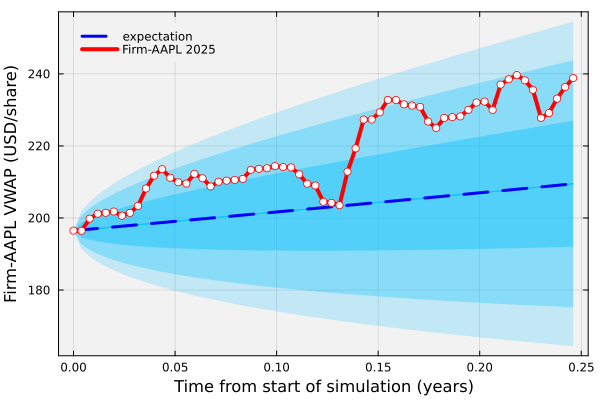

In [26]:
let

    # Compute mean-plus-or-minus-z-standard-deviation held-out price bands -
    L68 = oos_expectation[:,2] .- sqrt.(oos_variance[:,2]) # lower one-standard-deviation band
    U68 = oos_expectation[:,2] .+ sqrt.(oos_variance[:,2]) # upper one-standard-deviation band
    L95 = oos_expectation[:,2] .- 1.96*sqrt.(oos_variance[:,2]) # lower Normal-reference 95% band
    U95 = oos_expectation[:,2] .+ 1.96*sqrt.(oos_variance[:,2]) # upper Normal-reference 95% band
    L99 = oos_expectation[:,2] .- 2.576*sqrt.(oos_variance[:,2]) # lower Normal-reference 99% band
    U99 = oos_expectation[:,2] .+ 2.576*sqrt.(oos_variance[:,2]) # upper Normal-reference 99% band

    T_sim = oos_levels*Δt # elapsed time from the held-out root, trading years

    # Display model bands, expected price, and aligned held-out VWAP -
    plot(T_sim, oos_expectation[:,2], fillrange=L68, c=:deepskyblue1, alpha=0.4, label="")
    plot!(T_sim, oos_expectation[:,2], fillrange=U68, c=:deepskyblue1, alpha=0.4, label="")
    plot!(T_sim, oos_expectation[:,2], fillrange=L95, c=:deepskyblue1, alpha=0.3, label="")
    plot!(T_sim, oos_expectation[:,2], fillrange=U95, c=:deepskyblue1, alpha=0.3, label="")
    plot!(T_sim, oos_expectation[:,2], fillrange=L99, c=:deepskyblue1, alpha=0.2, label="")
    plot!(T_sim, oos_expectation[:,2], fillrange=U99, c=:deepskyblue1, alpha=0.2, label="")
    plot!(T_sim, oos_expectation[:,2], c=:blue, lw=3, ls=:dash, label="expectation")
    plot!(T_sim, oos_firm_data[oos_levels .+ oos_start_index, :volume_weighted_average_price],
        lw=4, c=:red, label="Firm-$(random_firm_ticker) 2025", legend = :topleft)
    scatter!(T_sim, oos_firm_data[oos_levels .+ oos_start_index, :volume_weighted_average_price], label="",
        msc=:red, mc=:white)

    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);

    xlabel!("Time from start of simulation (years)", fontsize=18)
    ylabel!("Firm-$(random_firm_ticker) VWAP (USD/share)", fontsize=18)
end

### Test every 2025 window

One random window is not enough. We test every 2025 start day with `TSIM` observations available. A window passes only when every observed price stays inside the model's $\pm 2.576\sigma$ band.

We compare two whole-window rates:

* `model_rate`: the fraction of model paths that stay inside the band.
* `observed_rate`: the fraction of 2025 market paths that stay inside the band.

The familiar 99% value applies to a Normal band at one time point, not to an entire path. The lattice is also discrete, so we compute its benchmark directly. At each level, the function removes probability outside the band and moves the remaining probability forward. Prices and bands scale together, so we can set $S_\circ = 1$.

In [27]:
# Compute the model-implied probability that an entire path remains inside its moment band -
function model_containment(u::Float64, d::Float64, p::Float64;
    z::Float64 = 2.576, h::Int64 = TSIM)::Float64

    # Build a reference tree; multiplicative scaling makes the containment probability independent of S₀ -
    S₀ = 1.0; # normalized root price
    lv = [k for k ∈ 0:(h - 1)]; # financial levels included in the containment event
    model = build(MyBinomialEquityPriceTree, (u = u, d = d, p = p)) |>
        (m -> populate(m, Sₒ = S₀, h = h));

    # Compute the lower and upper price bounds at every level -
    E = 𝔼(model, lv); # expected normalized price
    V = Var(model, lv); # normalized price variance
    LB = E[:,2] .- z*sqrt.(V[:,2]); # lower bound by level
    UB = E[:,2] .+ z*sqrt.(V[:,2]); # upper bound by level

    alive = [1.0]; # level 0 holds a single node, reached with probability 1
    for j ∈ 0:(h - 1) # financial level j maps to Julia positions j + 1

        # Remove probability outside the band -
        price = [S₀*u^k*d^(j - k) for k ∈ 0:j]; # level-j prices ordered by up-move count k
        alive = [(LB[j+1] <= price[k+1] <= UB[j+1]) ? alive[k+1] : 0.0 for k ∈ 0:j];
        j == h - 1 && break # no transition is needed after the last scored level

        # Propagate the remaining probability to the next level -
        next_level = zeros(j + 2); # survival probability at each node of level j + 1
        for k ∈ 0:j # source node indexed by its up-move count
            next_level[k+2] += p*alive[k+1];         # an up move
            next_level[k+1] += (1.0 - p)*alive[k+1]; # a down move
        end
        alive = next_level; # advance the surviving probability mass one level
    end

    return sum(alive); # probability that never left the band
end

model_containment (generic function with 1 method)

### Compare model and market coverage

Now score every valid 2025 window. The parameters estimated from 2014 to 2024 stay fixed; only the starting price changes.

In [28]:
# Score every complete TSIM-day window available in the held-out year -
number_of_oos_starts = number_of_oos_days - TSIM + 1; # count of admissible first rows

oos_success_rate = let

    # Initialize the nominal 99% band multiplier and success counter -
    z = 2.576; # Normal-reference standard-deviation multiplier
    successes = 0; # number of observed paths contained at every level

    for s ∈ 1:number_of_oos_starts # s is the first Julia row of one held-out window

        S = oos_firm_data[s, :volume_weighted_average_price]; # window-specific root VWAP, USD/share

        model = build(MyBinomialEquityPriceTree, (u = ū, d = d̄, p = p̄)) |>
            (m -> populate(m, Sₒ = S, h = TSIM));

        E = 𝔼(model, oos_levels); # expected price by level
        V = Var(model, oos_levels); # price variance by level
        LB = E[:,2] .- z*sqrt.(V[:,2]); # lower price bound
        UB = E[:,2] .+ z*sqrt.(V[:,2]); # upper price bound

        observed = [oos_firm_data[s + k - 1, :volume_weighted_average_price] for k ∈ 1:TSIM]; # aligned VWAP path
        successes += all(LB .<= observed .<= UB); # Bool contributes 1 only for full-window containment
    end

    successes/number_of_oos_starts; # empirical fraction of fully contained held-out windows
end

oos_model_rate = model_containment(ū, d̄, p̄); # model-implied full-path containment probability

println("$(random_firm_ticker): the model keeps its own paths inside the band for $(round(100*oos_model_rate, digits=1))% of windows")
println("$(random_firm_ticker): the observed 2025 price stayed inside the band for $(round(100*oos_success_rate, digits=1))% of the $(number_of_oos_starts) possible start days")

AAPL: the model keeps its own paths inside the band for 93.0% of windows


AAPL: the observed 2025 price stayed inside the band for 42.6% of the 188 possible start days


### Check more firms

The selected firm may be unusual. We repeat the test for six firms. For each firm, we estimate $(u,d,p)$ from 2014 to 2024 data and test every valid 2025 window.

In [29]:
# Repeat the exhaustive held-out coverage check for a small cross-section of firms -
oos_coverage_table = let

    # Initialize -
    z = 2.576; # Normal-reference multiplier for the widest band
    tickers_to_test = ["AAPL", "MSFT", "JNJ", "KO", "AMD", "NVDA"]; # illustrative sectors and volatilities
    table = DataFrame(); # one coverage-summary row per eligible ticker

    for ticker ∈ tickers_to_test # preserve the declared display order

        # Require both training and held-out data -
        (haskey(dataset, ticker) && haskey(testing_dataset, ticker)) || continue # require training and test histories

        # Estimate (u,d,p) from the 2014 to 2024 growth rates -
        (u,d,p) = (RealWorldBinomialProbabilityMeasure())(log_growth_matrix(dataset, ticker); Δt = Δt); # fitted daily factors and up frequency

        # Score every valid 2025 window -
        frame = testing_dataset[ticker]; # held-out 2025 DataFrame
        number_of_starts = nrow(frame) - TSIM + 1; # complete TSIM-day windows
        successes = 0; # fully contained observed paths

        for s ∈ 1:number_of_starts # first Julia row of one held-out window

            S = frame[s, :volume_weighted_average_price]; # window-specific root VWAP, USD/share
            model = build(MyBinomialEquityPriceTree, (u = u, d = d, p = p)) |>
                (m -> populate(m, Sₒ = S, h = TSIM));

            E = 𝔼(model, oos_levels); # expected price by level
            V = Var(model, oos_levels); # price variance by level
            LB = E[:,2] .- z*sqrt.(V[:,2]); # lower price bound
            UB = E[:,2] .+ z*sqrt.(V[:,2]); # upper price bound

            observed = [frame[s + k - 1, :volume_weighted_average_price] for k ∈ 1:TSIM]; # aligned VWAP path
            successes += all(LB .<= observed .<= UB); # count only full-window containment
        end

        push!(table, (ticker = ticker, u = u, d = d, p = p, # fitted parameters and two coverage rates
            model_rate = model_containment(u, d, p),
            observed_rate = successes/number_of_starts));
    end

    table; # return the cross-ticker summary from the let block
end;

# Display model-implied and observed full-path coverage side by side -
pretty_table(oos_coverage_table,
    table_format = TextTableFormat(borders = text_table_borders__compact))

 -------- --------- ---------- ---------- ------------ ---------------
  ticker         u          d          p   model_rate   observed_rate 
  String   Float64    Float64    Float64      Float64         Float64 
 -------- --------- ---------- ---------- ------------ ---------------
    AAPL   1.01059   0.989301   0.550976     0.930119        0.425532
    MSFT   1.00971   0.990361   0.548445     0.931013        0.617021
     JNJ   1.00681   0.993259   0.513015     0.930397        0.148936
      KO    1.0063   0.993208   0.534346     0.929693        0.664894
     AMD    1.0223   0.979554   0.517715     0.925709        0.345745
    NVDA   1.01791    0.98307   0.554591     0.928335        0.553191
 -------- --------- ---------- ---------- ------------ ---------------


### Interpret the results

The model predicts about 93% whole-window coverage for every firm. The observed 2025 rates are lower.

The fixed $u$ and $d$ factors imply fixed volatility, but real markets move through calm and turbulent periods. The model also carries the historical drift into 2025. These assumptions may explain the gap, but this test does not isolate the cause.

The main result is simple: a model can match a textbook example and pass an in-sample check, yet fail out of sample.

___

## Summary

This example built a binomial share-price lattice, verified its implementation against a known Hull example, estimated real-world lattice parameters from historical equity data, and then tested the calibrated model on 2025 prices it had never seen.

> __Key Takeaways:__
>
> * __A binomial lattice evolves through two one-step outcomes:__ Starting from the current price, the up factor, down factor, and transition probability fix which prices are reachable at each future step and the probability attached to each. Everything the model says about future risk follows from that starting point and those three numbers.
> * __Historical estimation turns the lattice into a real-world model:__ Observed growth-rate data supply the move magnitudes and the physical probability used for forecasting. That is a different calibration from the risk-neutral one used for valuation, and the two are not interchangeable.
> * __The out-of-sample test is the honest one:__ Parameters fit to a historical window keep later prices inside the model's own bands far less often than the model predicts for itself. An in-sample check scores the model on the same data that set its parameters, so it can look fine while the model still misstates the risk of the next period.

A lattice is useful only to the extent that its transition assumptions, parameter estimates, and validation criterion are appropriate for the question being asked.

___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products, or any investment or trading advice or strategy, is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.